In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

predicts_mansi_v1_Base = pd.read_csv('predicts_mansi_v1_Base.csv', delimiter="\t")
predicts_mansi_v1_Base['model'] = 'mansi_v1_Base'

predicts_mansi_v2_Hun = pd.read_csv('predicts_mansi_v2_Hun.csv', delimiter="\t")
predicts_mansi_v2_Hun['model'] = 'mansi_v2_Hun'

predicts_mansi_v3_Rus = pd.read_csv('predicts_mansi_v3_Rus.csv', delimiter="\t")
predicts_mansi_v3_Rus['model'] = 'mansi_v3_Rus'

predicts_mansi_v4_Hun_v2 = pd.read_csv('predicts_mansi_v4_Hun_v2.csv', delimiter="\t")
predicts_mansi_v4_Hun_v2['model'] = 'mansi_v4_Hun_v2'

predicts_mansi_v5_Rus = pd.read_csv('predicts_mansi_v5_Rus.csv', delimiter="\t")
predicts_mansi_v5_Rus['model'] = 'mansi_v5_Rus'


predicts_mansi_XTTSv2 = pd.read_csv('predicts_mansi_XTTSv2.csv', delimiter="\t")
predicts_mansi_XTTSv2['model'] = 'mansi_XTTSv2'

predicts_mansi_VITS = pd.read_csv('predicts_mansi_VITS.csv', delimiter="\t")
predicts_mansi_VITS['model'] = 'mansi_VITS'




predicts_F5TTS_rus = pd.read_csv('predicts_F5TTS_rus.csv', delimiter="\t")
predicts_F5TTS_rus['model'] = 'F5TTS_rus'

In [3]:
orig_dataset = pd.concat([
    # predicts_mansi_v1_Base, 
    # predicts_mansi_v2_Hun, 
    # predicts_mansi_v3_Rus,
    # predicts_mansi_v4_Hun_v2,
    predicts_mansi_v5_Rus,
    # predicts_mansi_XTTSv2,
    # predicts_mansi_VITS,
    predicts_F5TTS_rus
    ], ignore_index=True)

dataset = orig_dataset[orig_dataset['cer'] < 100]
dataset = dataset[dataset['wer'] < 100]

          model   mean wer   mean cer  mean orh_wer  mean orh_cer
0     F5TTS_rus  48.930750  15.611263     52.262123     16.576664
1  mansi_v5_Rus  12.345703   2.778366     17.072880      3.685526


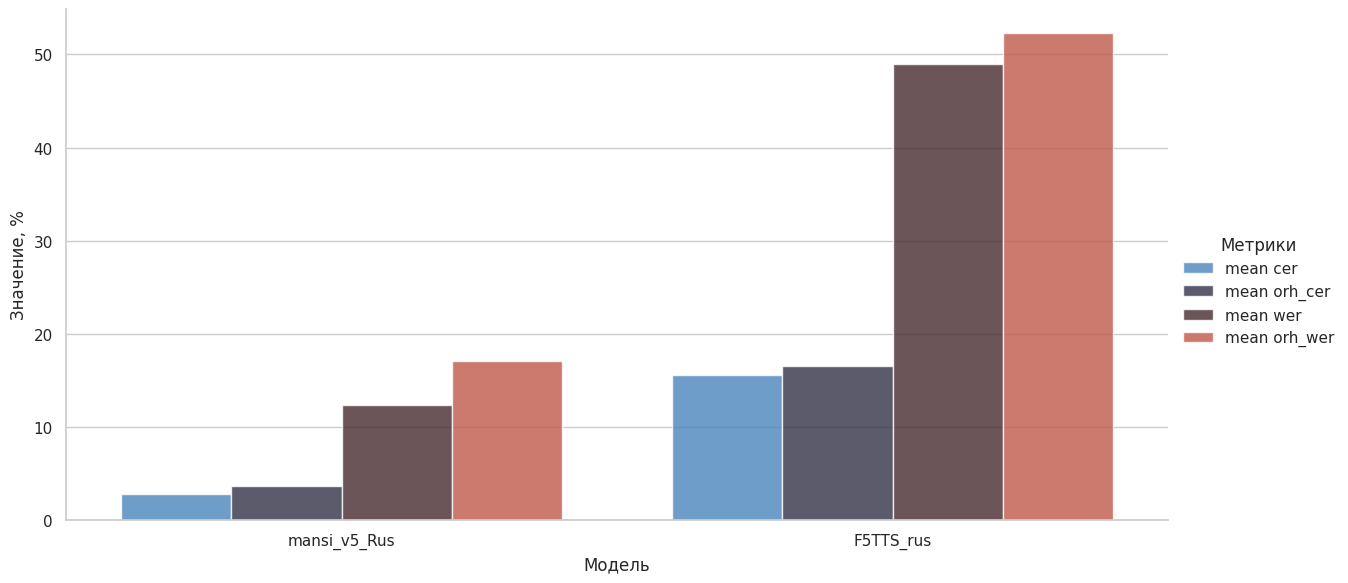

In [4]:
sns.set_theme(style="whitegrid")

data = dataset.drop(columns=['whisper_out', 'label', 'audio_file'])
data = data.groupby("model", as_index=False).mean()
data = data.rename(columns={
    'wer': 'mean wer',
    'cer': 'mean cer',
    'orh_wer': 'mean orh_wer',
    'orh_cer': 'mean orh_cer'
})
print(data)

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)



g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("tts mean метрики.png", dpi=600, bbox_inches="tight")

          model  median wer  median cer  median orh_wer  median orh_cer
0     F5TTS_rus        50.0   14.285714       52.402746       15.384615
1  mansi_v5_Rus         0.0    0.000000       10.000000        1.449275


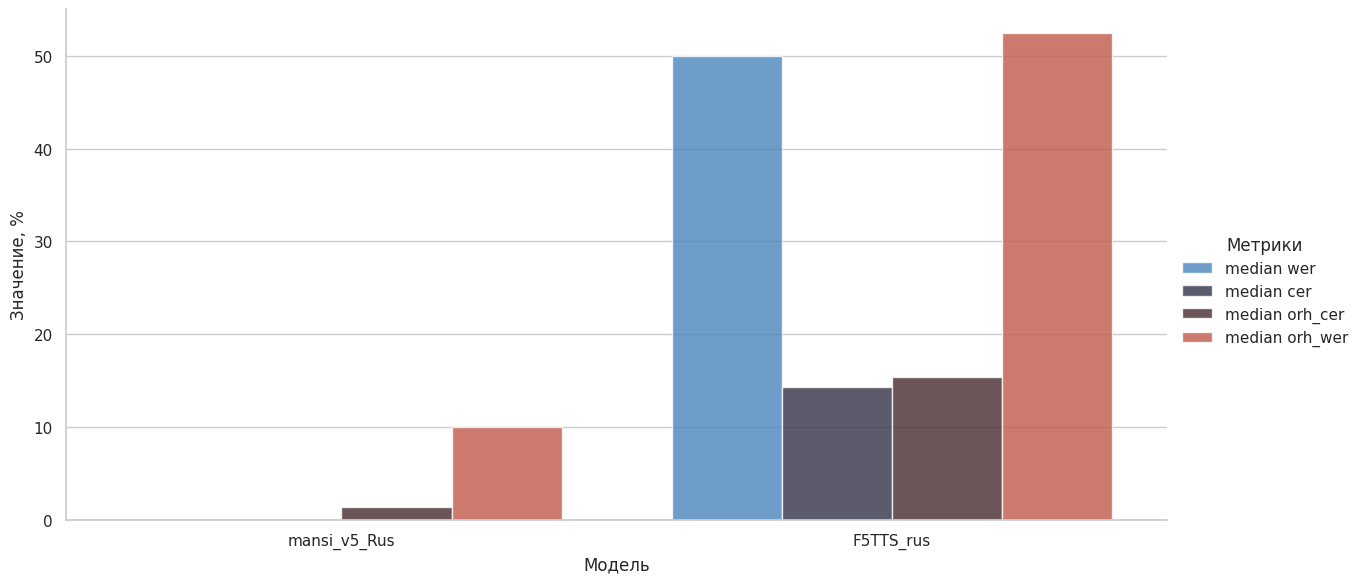

In [5]:
data = dataset.drop(columns=['whisper_out', 'label', 'audio_file'])
data = data.groupby("model", as_index=False).median()
data = data.rename(columns={
    'wer': 'median wer',
    'cer': 'median cer',
    'orh_wer': 'median orh_wer',
    'orh_cer': 'median orh_cer'
})
print(data)

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)

g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("tts median метрики.png", dpi=600, bbox_inches="tight")

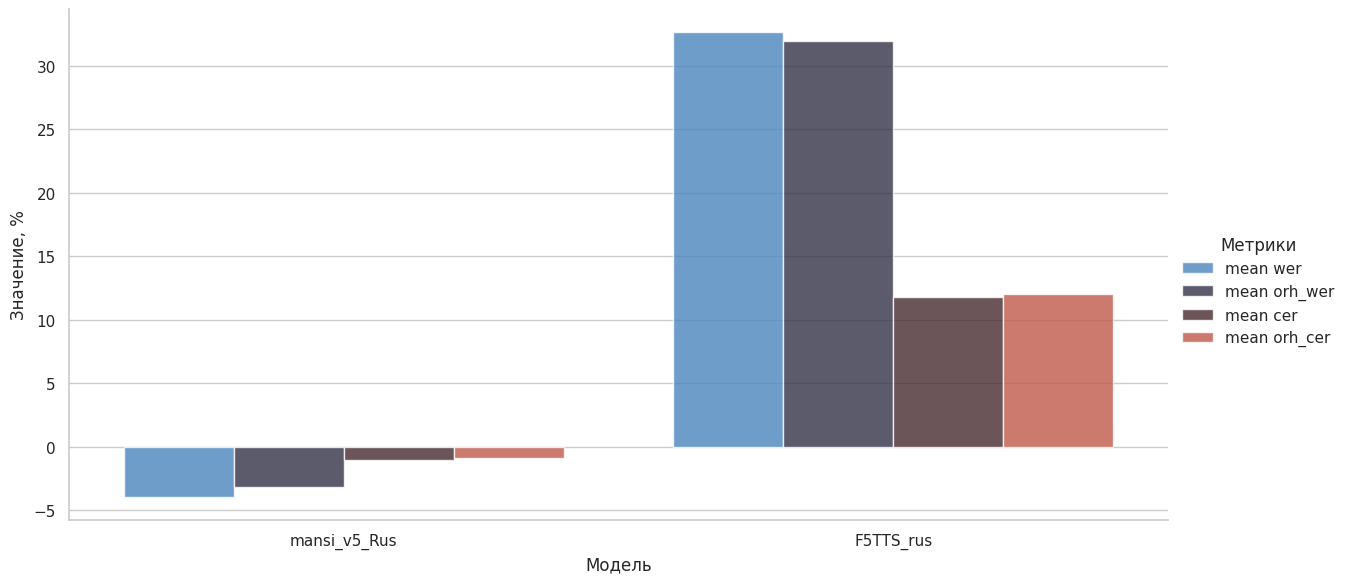

In [6]:
sns.set_theme(style="whitegrid")

data = dataset.drop(columns=['whisper_out', 'label', 'audio_file'])
data = data.groupby("model", as_index=False).mean()
data = data.rename(columns={
    'wer': 'mean wer',
    'cer': 'mean cer',
    'orh_wer': 'mean orh_wer',
    'orh_cer': 'mean orh_cer'
})

data['mean wer'] = data['mean wer'] - 16.273850
data['mean cer'] = data['mean cer'] - 3.770099
data['mean orh_wer'] = data['mean orh_wer'] - 20.263217
data['mean orh_cer'] = data['mean orh_cer'] - 4.566794

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)


g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("tts mean метрики bias.png", dpi=600, bbox_inches="tight")

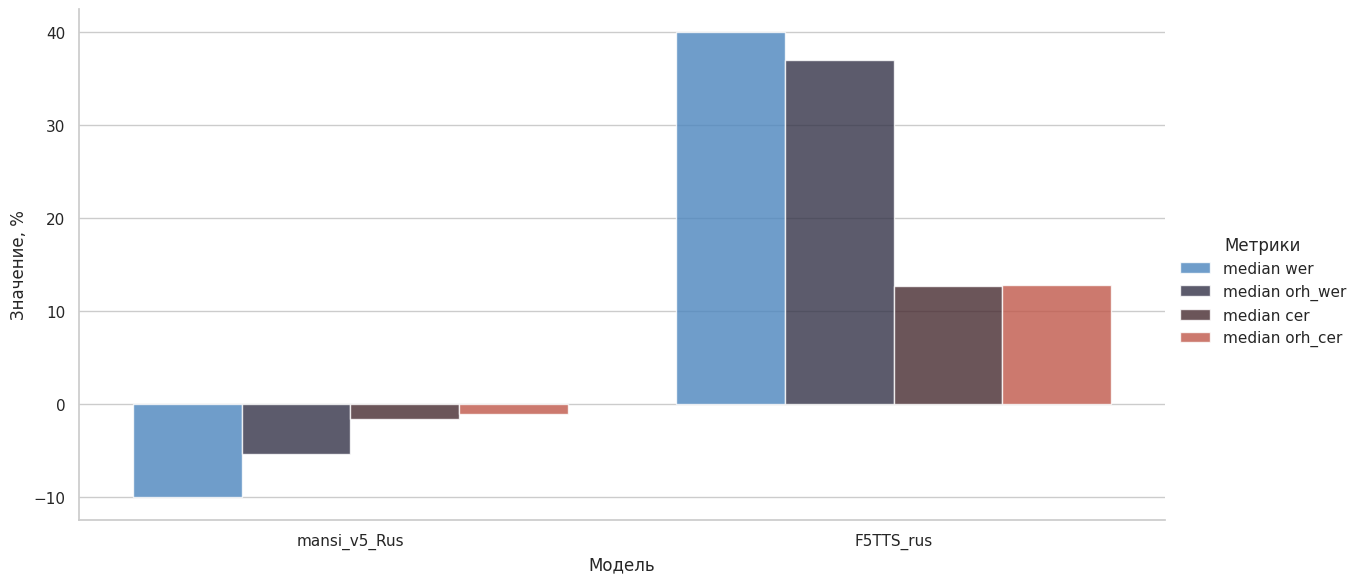

In [7]:
data = dataset.drop(columns=['whisper_out', 'label', 'audio_file'])
data = data.groupby("model", as_index=False).median()
data = data.rename(columns={
    'wer': 'median wer',
    'cer': 'median cer',
    'orh_wer': 'median orh_wer',
    'orh_cer': 'median orh_cer'
})

data['median wer'] = data['median wer'] - 10.000000
data['median cer'] = data['median cer'] - 1.612903
data['median orh_wer'] = data['median orh_wer'] - 15.384615
data['median orh_cer'] = data['median orh_cer'] - 2.564103

data = data.melt(
    id_vars=["model"],
    var_name="metrics",
    value_name="value"
)

data = data.sort_values("value", ascending=True)

g = sns.catplot(
    data=data, 
    kind="bar",
    x="model", 
    y="value", 
    hue="metrics",
    errorbar=None, 
    palette="icefire", 
    alpha=.8,
    height=6,
    aspect=2
)


g.set_axis_labels("Модель", "Значение, %")
g.legend.set_title("Метрики")
g.savefig("tts median метрики bias.png", dpi=600, bbox_inches="tight")

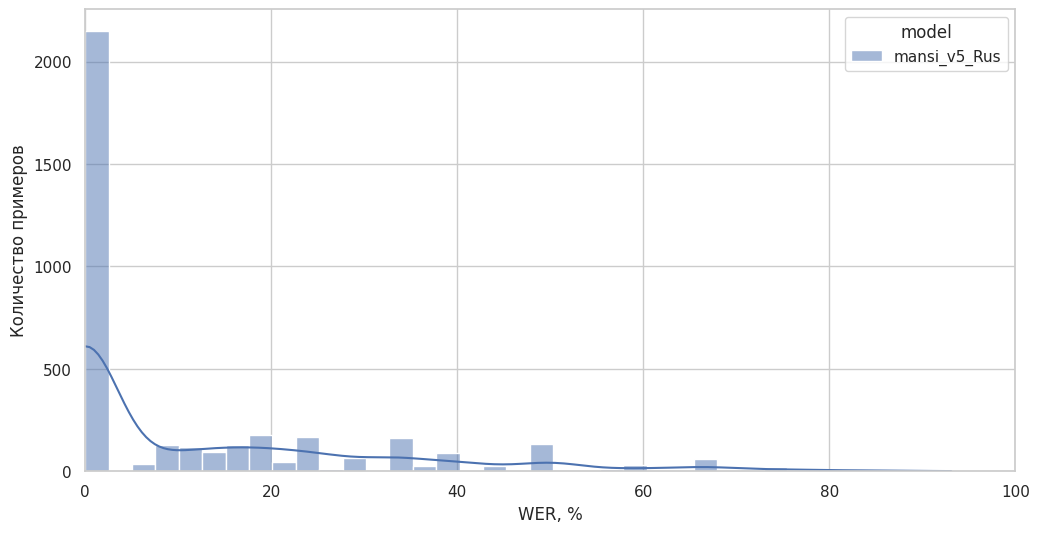

In [8]:
f, ax = plt.subplots(figsize=(12, 6))

data = dataset[dataset['model'] == 'mansi_v5_Rus']

sns.histplot(data=data[data['model'] == 'mansi_v5_Rus'], x="wer", hue="model", kde=True)

ax.set_xlim(0, 100)
ax.set(ylabel="Количество примеров")
ax.set(xlabel="WER, %")
# plt.legend(title="Тип")

plt.savefig("v5_Rus wer.png", dpi=600, bbox_inches="tight")

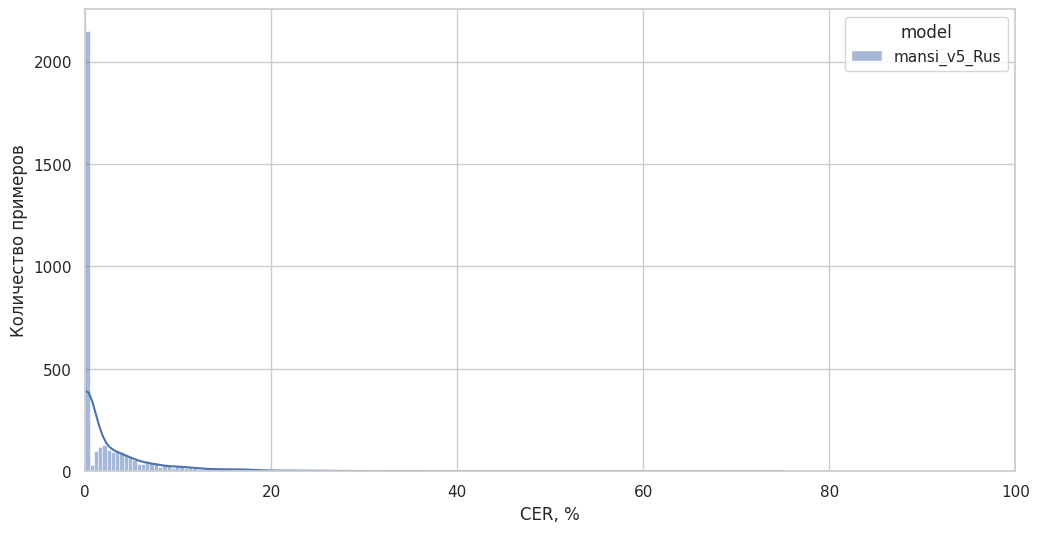

In [9]:
f, ax = plt.subplots(figsize=(12, 6))

data = dataset[dataset['model'] == 'mansi_v5_Rus']

sns.histplot(data=data, x="cer", hue="model", kde=True)

ax.set_xlim(0, 100)
ax.set(ylabel="Количество примеров")
ax.set(xlabel="CER, %")
# plt.legend(title="Тип")

plt.savefig("v5_Rus cer.png", dpi=600, bbox_inches="tight")

In [10]:
data = pd.DataFrame(columns=['model', 'dataset', 'count'])

data.loc[len(data)] = {"model": "mansi_v1_Base", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_v1_Base", "dataset": 'TTS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "mansi_v2_Hun", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_v2_Hun", "dataset": 'TTS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "mansi_v3_Rus", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_v3_Rus", "dataset": 'TTS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "mansi_v4_Hun_v2", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_v4_Hun_v2", "dataset": 'TTS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "mansi_v5_Rus", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_v5_Rus", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "mansi_v5_Rus", "dataset": 'BONUS Датасет', "count": 13798}


data.loc[len(data)] = {"model": "mansi_XTTSv2", "dataset": 'STT Датасет', "count": 8007}
data.loc[len(data)] = {"model": "mansi_XTTSv2", "dataset": 'TTS Датасет', "count": 12335}
data.loc[len(data)] = {"model": "mansi_XTTSv2", "dataset": 'BONUS Датасет', "count": 12335}


data.loc[len(data)] = {"model": "mansi_VITS", "dataset": 'TTS Датасет', "count": 12335}

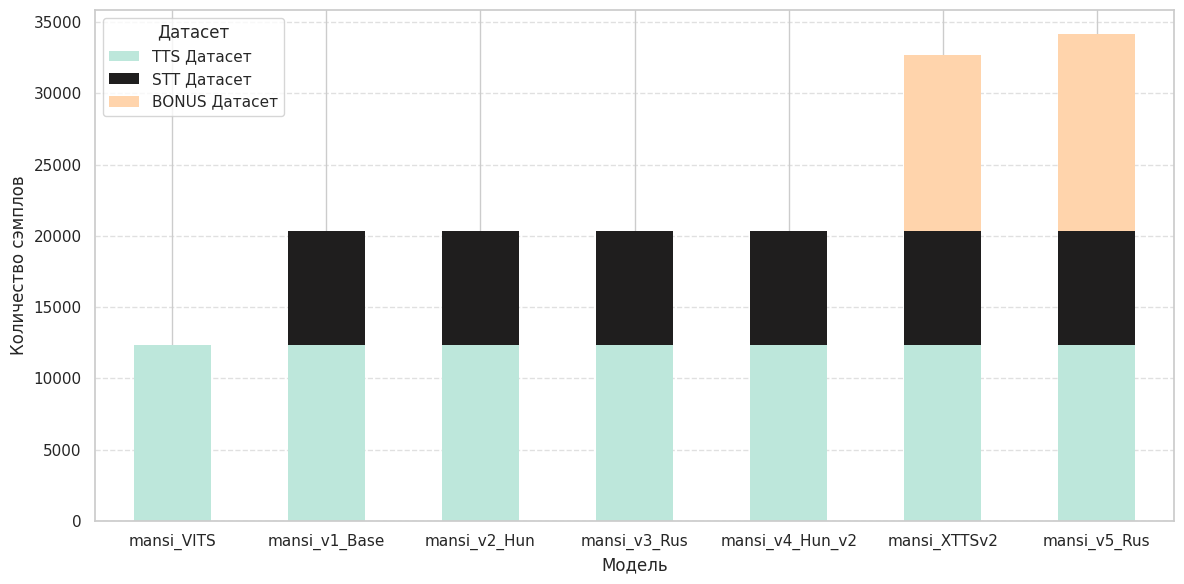

In [11]:
sns.set_theme(style="whitegrid")

pivot = data.pivot(index="model", columns="dataset", values="count")

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

order = ["TTS Датасет", "STT Датасет", "BONUS Датасет", "SYNTHETIC Датасет"]
pivot = pivot[[c for c in order if c in pivot.columns]]

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="icefire",
    edgecolor="none"
)

plt.ylabel("Количество сэмплов", fontsize=12)
plt.xlabel("Модель", fontsize=12)
plt.xticks(rotation=0, ha="center")

plt.legend(title="Датасет")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("распределние данных по tts моделям.png", dpi=600, bbox_inches="tight")